# Laboratorio 2 — Ejercicio 1: Modelos LSTM

Victor Manuel Pérez Chávez - 23731
Diego Oswaldo Flores Rivas - 23714
Juan Diego Solís Martínez - 23720

## Series seleccionadas

Seleccionamos **`Total`** y **`Turista + Excursionista`**:

- `Total` es la serie obligatoria y la de mayor volumen, usada como referencia principal
  en todo el trabajo previo.
- `Turista + Excursionista` fue identificada en el laboratorio anterior como la serie recomendada como referencia oficial:
  no tiene el quiebre metodológico que sí afecta a `Viajero`, tiene la mayor fuerza de tendencia y el mejor comportamiento
  estadístico general del grupo de "tipo de viajero".


## 0. Configuración, librerías y reproducibilidad

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
def fijar_semillas(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
fijar_semillas()

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

AZUL, NARANJA, VERDE, ROJO, GRIS, MORADO = "#2563eb", "#f59e0b", "#10b981", "#ef4444", "#94a3b8", "#8b5cf6"

def miles(x, pos):
    return f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
FMT_MILES = mticker.FuncFormatter(miles)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

DIR_PROC = Path("./data")
print("TensorFlow", tf.__version__)


I0000 00:00:1785449736.362808    5022 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1785449737.956522    5022 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 1. Carga de los conjuntos de entrenamiento y prueba

In [2]:
train = pd.read_csv(DIR_PROC / "series_mensuales_train.csv", index_col=0, parse_dates=True)
train.index.freq = pd.tseries.frequencies.to_offset("MS")

df_test = pd.read_csv(DIR_PROC / "test_filas.csv", parse_dates=["Fecha"])

test_total = df_test.groupby("Fecha")["Viajero"].sum().rename("Total").asfreq("MS")

test_tipo = (
    df_test.pivot_table(index="Fecha", columns="Tipo de Viajero", values="Viajero",
                         aggfunc="sum", observed=True)
    .fillna(0).sort_index()
)
test_tipo["Turista + Excursionista"] = test_tipo["Turista"] + test_tipo["Excursionista"]
test_tipo = test_tipo.asfreq("MS")

series_seleccionadas = {
    "Total": {"train": train["Total"], "test": test_total},
    "Turista + Excursionista": {"train": train["Turista + Excursionista"],
                                 "test": test_tipo["Turista + Excursionista"]},
}

for nombre, d in series_seleccionadas.items():
    print(f"{nombre}: train {d['train'].index.min().date()} -> {d['train'].index.max().date()} "
          f"({len(d['train'])} meses)  |  test {d['test'].index.min().date()} -> "
          f"{d['test'].index.max().date()} ({len(d['test'])} meses)")


Total: train 2009-01-01 -> 2021-03-01 (147 meses)  |  test 2021-04-01 -> 2026-06-01 (63 meses)
Turista + Excursionista: train 2009-01-01 -> 2021-03-01 (147 meses)  |  test 2021-04-01 -> 2026-06-01 (63 meses)


### Mejores modelos clásicos del laboratorio anterior

Se muestra como se obtuvieron en `04_05_analisis_series.ipynb`, las
métricas del **mejor modelo clásico por serie** (criterio: mínimo RMSE sobre el mismo
conjunto de prueba que se usa en este cuaderno).

In [3]:
baseline_clasico = pd.DataFrame([
    {"Serie": "Total", "Mejor modelo (Lab. anterior)": "ARIMA(0,d,1)(0,1,1)[12]",
     "MAE": 100904.37, "RMSE": 112078.02},
    {"Serie": "Turista + Excursionista", "Mejor modelo (Lab. anterior)": "ARIMA(0,d,1)(0,1,1)[12]",
     "MAE": 83404.78, "RMSE": 87818.90},
]).set_index("Serie")
baseline_clasico


,Mejor modelo (Lab. anterior),MAE,RMSE
Serie,,,
Total,"ARIMA(0,d,1)(0,1,1)[12]",100904.37,112078.02
Turista + Excursionista,"ARIMA(0,d,1)(0,1,1)[12]",83404.78,87818.90


## 2. Funciones auxiliares: ventanas, arquitecturas, tuneo y pronóstico recursivo

In [ ]:
def crear_ventanas(arr, w):
    X, y = [], []
    for i in range(len(arr) - w):
        X.append(arr[i:i + w])
        y.append(arr[i + w])
    return np.array(X), np.array(y)


def construir_lstm_simple(w, unidades):
    modelo = Sequential([
        Input(shape=(w, 1)),
        LSTM(unidades),
        Dense(1),
    ])
    modelo.compile(optimizer="adam", loss="mse")
    return modelo


def construir_lstm_apilada(w, unidades1, unidades2, dropout):
    modelo = Sequential([
        Input(shape=(w, 1)),
        LSTM(unidades1, return_sequences=True),
        Dropout(dropout),
        LSTM(unidades2),
        Dropout(dropout),
        Dense(1),
    ])
    modelo.compile(optimizer="adam", loss="mse")
    return modelo


CONSTRUCTORES = {"LSTM simple": construir_lstm_simple, "LSTM apilada (2 capas + dropout)": construir_lstm_apilada}


def tunear_arquitectura(nombre_arq, constructor, grid, s_scaled, epochs=200, batch_size=8, n_val=12):
    filas = []
    for cfg in grid:
        w = cfg["w"]
        X, y = crear_ventanas(s_scaled, w)
        X_tr, y_tr = X[:-n_val], y[:-n_val]
        X_val, y_val = X[-n_val:], y[-n_val:]
        X_tr = X_tr.reshape(-1, w, 1)
        X_val = X_val.reshape(-1, w, 1)

        fijar_semillas()
        params = {k: v for k, v in cfg.items() if k != "w"}
        modelo = constructor(w, **params)
        es = EarlyStopping(patience=15, restore_best_weights=True)
        modelo.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs,
                   batch_size=batch_size, verbose=0, callbacks=[es])

        pred_val = modelo.predict(X_val, verbose=0).flatten()
        pred_val_inv = scaler.inverse_transform(pred_val.reshape(-1, 1)).flatten()
        y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
        val_rmse = rmse(y_val_inv, pred_val_inv)
        val_mae = mean_absolute_error(y_val_inv, pred_val_inv)

        filas.append({**cfg, "arquitectura": nombre_arq, "val_MAE": val_mae, "val_RMSE": val_rmse})

    tabla = pd.DataFrame(filas).sort_values("val_RMSE").reset_index(drop=True)
    mejor_cfg = {k: v for k, v in tabla.iloc[0].to_dict().items() if k not in ("arquitectura", "val_MAE", "val_RMSE")}
    mejor_cfg = {k: (int(v) if not isinstance(v, float) or v == int(v) else v) for k, v in mejor_cfg.items()}
    return tabla, mejor_cfg


def entrenar_final_y_pronosticar(constructor, cfg, s_scaled, horizonte, epochs=80, batch_size=8):
    w = cfg["w"]
    params = {k: v for k, v in cfg.items() if k != "w"}
    X, y = crear_ventanas(s_scaled, w)
    X = X.reshape(-1, w, 1)

    fijar_semillas()
    modelo = constructor(w, **params)
    historia = modelo.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=0)

    ventana = list(s_scaled[-w:])
    preds_escaladas = []
    for _ in range(horizonte):
        x_in = np.array(ventana[-w:]).reshape(1, w, 1)
        p = modelo.predict(x_in, verbose=0)[0, 0]
        preds_escaladas.append(p)
        ventana.append(p)

    preds = scaler.inverse_transform(np.array(preds_escaladas).reshape(-1, 1)).flatten()
    return modelo, historia, preds


### Grids de hiperparámetros usados para el tuneo (ambas series)

In [5]:
GRID_SIMPLE = [
    {"w": 6, "unidades": 16},
    {"w": 6, "unidades": 32},
    {"w": 12, "unidades": 32},
    {"w": 12, "unidades": 64},
]
GRID_APILADA = [
    {"w": 12, "unidades1": 32, "unidades2": 16, "dropout": 0.2},
    {"w": 12, "unidades1": 64, "unidades2": 32, "dropout": 0.1},
    {"w": 18, "unidades1": 64, "unidades2": 32, "dropout": 0.2},
]
print("GRID_SIMPLE:", GRID_SIMPLE)
print("GRID_APILADA:", GRID_APILADA)


GRID_SIMPLE: [{'w': 6, 'unidades': 16}, {'w': 6, 'unidades': 32}, {'w': 12, 'unidades': 32}, {'w': 12, 'unidades': 64}]
GRID_APILADA: [{'w': 12, 'unidades1': 32, 'unidades2': 16, 'dropout': 0.2}, {'w': 12, 'unidades1': 64, 'unidades2': 32, 'dropout': 0.1}, {'w': 18, 'unidades1': 64, 'unidades2': 32, 'dropout': 0.2}]


## 3. Serie: Total

### 3.1 Preparación de los datos (escalado y ventanas)

In [6]:
nombre_serie = "Total"
s_train = series_seleccionadas[nombre_serie]["train"].asfreq("MS")
s_test = series_seleccionadas[nombre_serie]["test"].asfreq("MS")
horizonte = len(s_test)

scaler = MinMaxScaler()
s_scaled = scaler.fit_transform(s_train.values.reshape(-1, 1)).flatten()

print(nombre_serie, "-", len(s_train), "meses de entrenamiento escalados a [0, 1] con MinMaxScaler")
print("Horizonte de pronostico (conjunto de prueba):", horizonte, "meses")


Total - 147 meses de entrenamiento escalados a [0, 1] con MinMaxScaler
Horizonte de pronostico (conjunto de prueba): 63 meses


### 3.2 Modelo A: LSTM simple (1 capa): tuneo de hiperparámetros

In [7]:
tabla_simple_total, mejor_simple_total = tunear_arquitectura(
    "LSTM simple", construir_lstm_simple, GRID_SIMPLE, s_scaled
)
print(tabla_simple_total.to_string(index=False))
print()
print("Mejor configuracion (LSTM simple):", mejor_simple_total)


 w  unidades arquitectura       val_MAE      val_RMSE
 6        16  LSTM simple  55454.644662  73037.566375
 6        32  LSTM simple  63546.307423  85022.150185
12        32  LSTM simple 102232.958464 125249.293211
12        64  LSTM simple 148236.438933 184372.724767

Mejor configuracion (LSTM simple): {'w': 6, 'unidades': 16}


### 3.3 Modelo B: LSTM apilada (2 capas + dropout) -- tuneo de hiperparámetros

In [8]:
tabla_apilada_total, mejor_apilada_total = tunear_arquitectura(
    "LSTM apilada (2 capas + dropout)", construir_lstm_apilada, GRID_APILADA, s_scaled
)
print(tabla_apilada_total.to_string(index=False))
print()
print("Mejor configuracion (LSTM apilada):", mejor_apilada_total)


 w  unidades1  unidades2  dropout                     arquitectura       val_MAE      val_RMSE
12         32         16      0.2 LSTM apilada (2 capas + dropout) 175647.844532 206681.504493
12         64         32      0.1 LSTM apilada (2 capas + dropout) 181571.519011 213883.127424
18         64         32      0.2 LSTM apilada (2 capas + dropout) 206474.367276 235969.541142

Mejor configuracion (LSTM apilada): {'w': 12, 'unidades1': 32, 'unidades2': 16, 'dropout': 0.2}


### 3.4 Entrenamiento final (con todo el conjunto de entrenamiento) y pronóstico recursivo

In [9]:
modelo_simple_total, hist_simple_total, pred_simple_total = entrenar_final_y_pronosticar(
    construir_lstm_simple, mejor_simple_total, s_scaled, horizonte
)
modelo_apilada_total, hist_apilada_total, pred_apilada_total = entrenar_final_y_pronosticar(
    construir_lstm_apilada, mejor_apilada_total, s_scaled, horizonte
)

pred_simple_total = pd.Series(pred_simple_total, index=s_test.index)
pred_apilada_total = pd.Series(pred_apilada_total, index=s_test.index)

comparacion_lstm_total = pd.DataFrame([
    {"Modelo": "LSTM simple", "w": mejor_simple_total["w"],
     "MAE": mean_absolute_error(s_test, pred_simple_total), "RMSE": rmse(s_test, pred_simple_total)},
    {"Modelo": "LSTM apilada (2 capas + dropout)", "w": mejor_apilada_total["w"],
     "MAE": mean_absolute_error(s_test, pred_apilada_total), "RMSE": rmse(s_test, pred_apilada_total)},
]).sort_values("RMSE").reset_index(drop=True)

print("Desempeno de los 2 modelos LSTM sobre el conjunto de prueba real (total):")
print(comparacion_lstm_total.to_string(index=False))


Desempeno de los 2 modelos LSTM sobre el conjunto de prueba real (total):
                          Modelo  w          MAE          RMSE
                     LSTM simple  6 83592.889276 105167.050389
LSTM apilada (2 capas + dropout) 12 92457.259192 115491.451462


### 3.5 Curvas de entrenamiento y pronóstico del mejor modelo LSTM

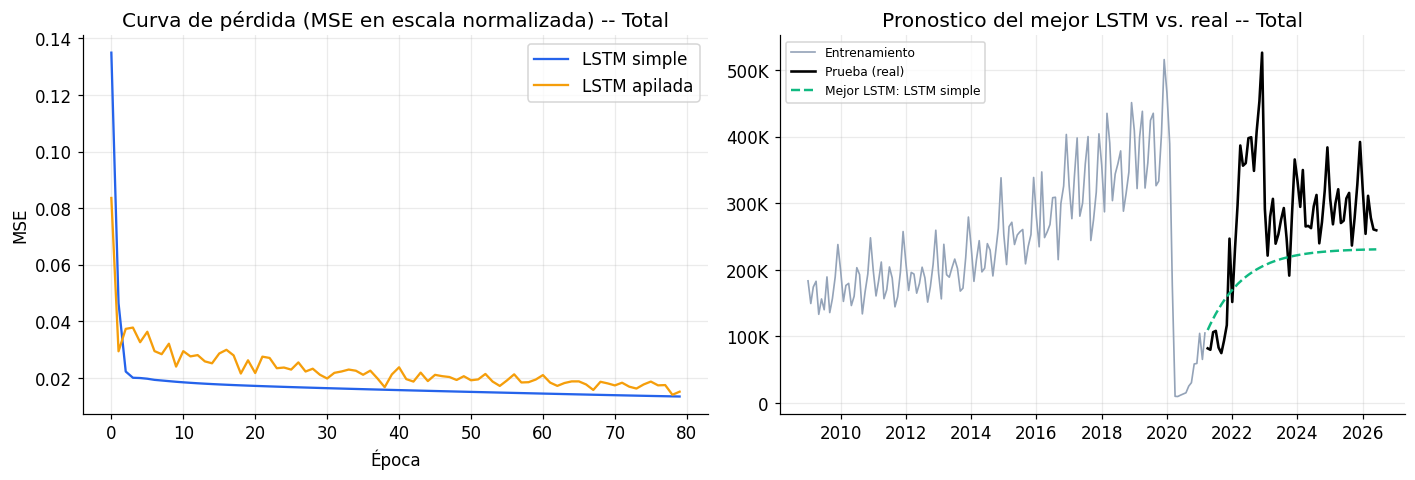

Mejor modelo LSTM para Total: LSTM simple
MAE = 83592.89
RMSE = 105167.05


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(hist_simple_total.history["loss"], color=AZUL, label="LSTM simple")
axes[0].plot(hist_apilada_total.history["loss"], color=NARANJA, label="LSTM apilada")
axes[0].set_title("Curva de pérdida (MSE en escala normalizada) -- Total")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE"); axes[0].legend()

mejor_modelo_lstm_total = comparacion_lstm_total.iloc[0]["Modelo"]
pred_mejor_lstm_total = pred_simple_total if mejor_modelo_lstm_total == "LSTM simple" else pred_apilada_total

axes[1].plot(s_train.index, s_train.values, color=GRIS, linewidth=1.1, label="Entrenamiento")
axes[1].plot(s_test.index, s_test.values, color="black", linewidth=1.7, label="Prueba (real)")
axes[1].plot(s_test.index, pred_mejor_lstm_total.values, color=VERDE, linestyle="--",
             linewidth=1.6, label="Mejor LSTM: " + mejor_modelo_lstm_total)
axes[1].yaxis.set_major_formatter(FMT_MILES)
axes[1].set_title("Pronostico del mejor LSTM vs. real -- Total")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Mejor modelo LSTM para Total:", mejor_modelo_lstm_total)
print("MAE =", round(mean_absolute_error(s_test, pred_mejor_lstm_total), 2))
print("RMSE =", round(rmse(s_test, pred_mejor_lstm_total), 2))


## 4. Serie: Turista + Excursionista

### 4.1 Preparación de los datos (escalado y ventanas)

In [11]:
nombre_serie = "Turista + Excursionista"
s_train = series_seleccionadas[nombre_serie]["train"].asfreq("MS")
s_test = series_seleccionadas[nombre_serie]["test"].asfreq("MS")
horizonte = len(s_test)

scaler = MinMaxScaler()
s_scaled = scaler.fit_transform(s_train.values.reshape(-1, 1)).flatten()

print(nombre_serie, "-", len(s_train), "meses de entrenamiento escalados a [0, 1] con MinMaxScaler")
print("Horizonte de pronostico (conjunto de prueba):", horizonte, "meses")


Turista + Excursionista - 147 meses de entrenamiento escalados a [0, 1] con MinMaxScaler
Horizonte de pronostico (conjunto de prueba): 63 meses


### 4.2 Modelo A: LSTM simple (1 capa) -- tuneo de hiperparámetros

In [12]:
tabla_simple_te, mejor_simple_te = tunear_arquitectura(
    "LSTM simple", construir_lstm_simple, GRID_SIMPLE, s_scaled
)
print(tabla_simple_te.to_string(index=False))
print()
print("Mejor configuracion (LSTM simple):", mejor_simple_te)


 w  unidades arquitectura       val_MAE      val_RMSE
 6        16  LSTM simple  49121.731621  62968.295164
 6        32  LSTM simple  55592.194512  73547.674196
12        32  LSTM simple  89000.677260 109084.064952
12        64  LSTM simple 127817.554213 158936.898657

Mejor configuracion (LSTM simple): {'w': 6, 'unidades': 16}
